# 1. Processamento de Dados + EDA

Case Tecnico Data Science - iFood

Objetivo deste notebook:
- Ingestao e limpeza de `offers.json`, `profile.json` e `transactions.json`
- Unificacao em uma tabela de oportunidades (grao: uma linha por instancia de "offer received")
- Analise exploratoria (EDA) sobre essa tabela
- Persistencia do resultado em `data/processed/` para o notebook de modelagem

Implementado em PySpark, conforme exigido pelo case.

## Resumo executivo

- **76.277 oportunidades** (ofertas enviadas) analisadas, de **17.000 clientes** e **10 ofertas**
  distintas (bogo, discount, informational), ao longo de **6 rodadas de envio sincronizadas**
  (dias 0, 7, 14, 17, 21 e 24 do teste).
- **Funil bogo/discount:** ~76-83% visualizam a oferta recebida, e ~51-59% completam — a
  diferenca entre visualizar e completar e onde a segmentacao pode ganhar eficiencia.
- **Ofertas informational** (sem mecanica de desconto) geram transacao subsequente em **39,1%**
  dos casos em que foram visualizadas.
- **Genero e um sinal forte:** mulheres completam mais que homens em **todas** as faixas etarias
  (ex.: 45-54 anos: 71,8% F vs 55,8% M).
- **Perfil incompleto correlaciona com baixa conversao:** os ~12,8% de clientes sem
  idade/genero/limite completam so **14,7%** das ofertas, bem abaixo de qualquer segmento com
  dado completo (50-70%+).
- **Tipo de oferta pesa mais que canal ou duracao:** discount supera bogo em quase todo canal;
  dentro do mesmo tipo, variar a duracao muda a completion rate em poucos pontos percentuais.
- **Quem completa oferta gasta ~4x mais** (mediana R$11,36 vs R$2,15) — mas isso e correlacao
  (autosselecao de clientes engajados), nao uma prova de causalidade da oferta.
- Ha uma pequena sobreposicao de janela entre reenvios da mesma oferta ao mesmo cliente que
  conta ~0,15% das conclusoes duas vezes — documentado e aceito como simplificacao.

Os detalhes e os numeros exatos de cada ponto estao nas secoes abaixo.

## Setup

In [1]:
import os

# Necessario no Windows: sem isso o Spark tenta chamar o "python" do PATH (que pode
# resolver para o stub da Microsoft Store) para os workers, e o processo falha ao conectar.
# cwd do kernel Jupyter e a pasta notebooks/, entao o venv fica um nivel acima.
_venv_python = os.path.abspath(os.path.join(os.getcwd(), "..", ".venv", "Scripts", "python.exe"))
os.environ["PYSPARK_PYTHON"] = _venv_python
os.environ["PYSPARK_DRIVER_PYTHON"] = _venv_python
# Ajuste o JAVA_HOME abaixo se o seu JDK/JRE estiver em outro caminho.
os.environ.setdefault("JAVA_HOME", r"C:\Program Files\Java\jre1.8.0_491")
# winutils.exe / hadoop.dll necessarios para o Spark gravar arquivos localmente no Windows
# (Hadoop LocalFileSystem). hadoop.dll precisa estar no PATH para o Windows conseguir carregar
# a biblioteca nativa (nao basta HADOOP_HOME apontar para a pasta).
os.environ.setdefault("HADOOP_HOME", r"C:\hadoop")
os.environ["PATH"] = os.environ["HADOOP_HOME"] + r"\bin;" + os.environ["PATH"]

import sys
sys.path.insert(0, "../src")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import data_processing as dp

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("ifood_offer_optimization")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")  # dataset pequeno, 200 partições default so gera overhead
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# Paleta validada (skill de dataviz): cor por identidade em ordem fixa, nunca ciclada.
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
CAT_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]  # blue, aqua, yellow, green, violet
COLOR_PRIMARY = CAT_COLORS[0]
UNKNOWN_COLOR = MUTED  # "Unknown" nao e uma categoria de identidade, e ausencia de dado
GENDER_ORDER = ["F", "M", "O", "Unknown"]

# Rampa sequencial azul (para magnitude / heatmaps / ordinal), do claro pro escuro
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)

def style_ax(ax):
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

spark

## 1. Carregamento dos dados brutos

Os 3 arquivos ficam em `data/raw/` (baixados do link fornecido no case, ver README).

In [2]:
offers = spark.read.json("../data/raw/offers.json")
profile = spark.read.json("../data/raw/profile.json")
transactions = spark.read.json("../data/raw/transactions.json")

print("offers:", offers.count(), "linhas")
print("profile:", profile.count(), "linhas")
print("transactions:", transactions.count(), "linhas")

transactions.printSchema()

offers: 10 linhas


profile: 17000 linhas


transactions: 306534 linhas
root
 |-- account_id: string (nullable = true)
 |-- event: string (nullable = true)
 |-- time_since_test_start: double (nullable = true)
 |-- value: struct (nullable = true)
 |    |-- amount: double (nullable = true)
 |    |-- offer id: string (nullable = true)
 |    |-- offer_id: string (nullable = true)
 |    |-- reward: double (nullable = true)



In [3]:
offers.show(10, truncate=False)

+----------------------------+--------------+--------+--------------------------------+---------+-------------+
|channels                    |discount_value|duration|id                              |min_value|offer_type   |
+----------------------------+--------------+--------+--------------------------------+---------+-------------+
|[email, mobile, social]     |10            |7.0     |ae264e3637204a6fb9bb56bc8210ddfd|10       |bogo         |
|[web, email, mobile, social]|10            |5.0     |4d5c57ea9a6940dd891ad53e9dbe8da0|10       |bogo         |
|[web, email, mobile]        |0             |4.0     |3f207df678b143eea3cee63160fa8bed|0        |informational|
|[web, email, mobile]        |5             |7.0     |9b98b8c7a33c4b65b9aebfe6a799e6d9|5        |bogo         |
|[web, email]                |5             |10.0    |0b1e1539f2cc45b7b9fa7c272da2e1d7|20       |discount     |
|[web, email, mobile, social]|3             |7.0     |2298d6c36e964ae4a3e7e9706d1fb8c2|7        |discoun

Observacao sobre o schema de `transactions`: o campo aninhado `value` traz o id da oferta em
DUAS chaves inconsistentes — `offer_id` e `` `offer id` `` (com espaco) — dependendo da linha.
Isso e tratado na etapa de achatamento abaixo (`dp.flatten_transactions`).

### 1.1 Checagem de qualidade dos dados brutos

In [4]:
# Checagem formal de nulos por tabela bruta, antes de qualquer limpeza.
raw_tables = [
    ("offers", offers, ["id", "offer_type", "duration", "channels"]),
    ("profile", profile, ["id", "gender", "age", "credit_card_limit"]),
    ("transactions", transactions, ["account_id", "event", "time_since_test_start", "value"]),
]

for name, df, cols in raw_tables:
    total = df.count()
    print(f"-- {name} (n={total}) --")
    for c in cols:
        n_null = df.filter(F.col(c).isNull()).count()
        print(f"  {c}: {n_null} nulos ({n_null/total:.1%})")
    print()

-- offers (n=10) --


  id: 0 nulos (0.0%)
  offer_type: 0 nulos (0.0%)


  duration: 0 nulos (0.0%)


  channels: 0 nulos (0.0%)



-- profile (n=17000) --


...

-- transactions (n=306534) --


  account_id: 0 nulos (0.0%)


  event: 0 nulos (0.0%)


  time_since_test_start: 0 nulos (0.0%)


  value: 0 nulos (0.0%)



**Decisoes de tratamento:**
- `offers` e `transactions`: sem nulos em nenhuma coluna-chave — nao precisa de imputacao.
- `profile`: `gender` e `credit_card_limit` tem exatamente **2.175 nulos (12,8%)** cada — o mesmo
  grupo de clientes (os que tem `age == 118`, o sentinel de idade nao informada). Ou seja, e um
  unico grupo de "perfil incompleto", nao três problemas independentes. Tratamento: `age` vira
  null, `gender` vira `"Unknown"`, e `credit_card_limit` fica null mesmo (ver secao 2).

## 2. Limpeza do `profile`

In [5]:
# Premissas:
# - age == 118 e um sentinel de "idade nao informada" -> tratado como null
# - gender fora de {F, M, O} (incluindo null) -> "Unknown"
profile_clean = dp.clean_profile(profile)

n_total = profile_clean.count()
n_incomplete = profile_clean.filter(F.col("age").isNull()).count()
print(f"Clientes com perfil incompleto (age=118 -> null): {n_incomplete} de {n_total} ({n_incomplete/n_total:.1%})")

profile_clean.groupBy("gender").count().show()

Clientes com perfil incompleto (age=118 -> null): 2175 de 17000 (12.8%)


+-------+-----+
| gender|count|
+-------+-----+
|      F| 6129|
|      M| 8484|
|Unknown| 2175|
|      O|  212|
+-------+-----+



## 3. Achatamento das `transactions`

In [6]:
tx_flat = dp.flatten_transactions(transactions)
tx_flat.select("account_id", "event", "time_since_test_start", "offer_id", "amount", "reward").show(5, truncate=False)

+--------------------------------+--------------+---------------------+--------------------------------+------+------+
|account_id                      |event         |time_since_test_start|offer_id                        |amount|reward|
+--------------------------------+--------------+---------------------+--------------------------------+------+------+
|78afa995795e4d85b5d9ceeca43f5fef|offer received|0.0                  |9b98b8c7a33c4b65b9aebfe6a799e6d9|NULL  |NULL  |
|a03223e636434f42ac4c3df47e8bac43|offer received|0.0                  |0b1e1539f2cc45b7b9fa7c272da2e1d7|NULL  |NULL  |
|e2127556f4f64592b11af22de27a7932|offer received|0.0                  |2906b810c7d4411798c6938adc9daaa5|NULL  |NULL  |
|8ec6ce2a7e7949b1bf142def7d0e0586|offer received|0.0                  |fafdcd668e3743c1bb461111dcafc2a4|NULL  |NULL  |
|68617ca6246f4fbc85e91a2a49552598|offer received|0.0                  |4d5c57ea9a6940dd891ad53e9dbe8da0|NULL  |NULL  |
+--------------------------------+--------------

In [7]:
# Evidencia: reward concedido em "offer completed" bate 100% com o discount_value da oferta
# (checagem feita contra os dados unificados na secao de qualidade mais abaixo tambem)
check = (
    tx_flat.filter(F.col("event") == "offer completed")
    .join(offers.select(F.col("id").alias("offer_id"), "discount_value"), on="offer_id", how="left")
    .select((F.col("reward") == F.col("discount_value")).alias("matches"))
    .groupBy("matches").count()
)
check.show()

+-------+-----+
|matches|count|
+-------+-----+
|   true|33579|
+-------+-----+



## 4. Join unificado (event log enriquecido)

In [8]:
df_joined = dp.build_joined_event_log(tx_flat, profile_clean, offers).cache()
print("df_joined:", df_joined.count(), "linhas (esperado = total de eventos em transactions.json)")
df_joined.show(5, truncate=False)

df_joined: 306534 linhas (esperado = total de eventos em transactions.json)
+--------------------------------+--------------+---------------------+--------------------------------+------+------+----+-------+-----------------+------------------+----------+---------+--------+--------------+----------------------------+
|customer_id                     |event         |time_since_test_start|offer_id                        |amount|reward|age |gender |credit_card_limit|registered_on_date|offer_type|min_value|duration|discount_value|channels                    |
+--------------------------------+--------------+---------------------+--------------------------------+------+------+----+-------+-----------------+------------------+----------+---------+--------+--------------+----------------------------+
|78afa995795e4d85b5d9ceeca43f5fef|offer received|0.0                  |9b98b8c7a33c4b65b9aebfe6a799e6d9|NULL  |NULL  |75  |F      |100000.0         |2017-05-09        |bogo      |5        |7.0   

## 5. Tabela de oportunidades

Grao: uma linha por instancia de `offer received` (`customer_id`, `offer_id`, `t_received`).
Cada instancia casa com `offer viewed` / `offer completed` **apenas dentro da sua propria janela**
`[t_received, t_received + duration]` — importante porque um mesmo cliente pode receber a mesma
oferta mais de uma vez, e cada envio deve ser avaliado de forma independente.

Tambem adicionamos `round_day`, o dia do teste em que a oferta foi enviada (o log historico roda
em 6 rodadas sincronizadas: dias 0, 7, 14, 17, 21 e 24 — confirmado por inspecao direta dos dados).

In [9]:
opps = dp.build_opportunities(df_joined).cache()
opps_full = dp.add_informational_success(opps, df_joined).cache()

print("Tabela de oportunidades:", opps_full.count(), "linhas (esperado = total de eventos 'offer received')")
opps_full.printSchema()

Tabela de oportunidades: 76277 linhas (esperado = total de eventos 'offer received')
root
 |-- customer_id: string (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- offer_type: string (nullable = true)
 |-- duration: double (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- min_value: long (nullable = true)
 |-- discount_value: long (nullable = true)
 |-- channels: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- t_received: double (nullable = true)
 |-- t_expires: double (nullable = true)
 |-- round_day: integer (nullable = true)
 |-- t_viewed: double (nullable = true)
 |-- t_completed: double (nullable = true)
 |-- viewed: integer (nullable = false)
 |-- completed: integer (nullable = false)
 |-- opp_id: long (nullable = false)
 |-- informational_success: integer (nullable = true)



## 6. Analise Exploratoria (EDA)

### 6.1 Distribuicoes univariadas: idade, limite de credito, genero, canais

Direto nos dados brutos (`profile`/`offers`, ja limpos), antes de qualquer cruzamento com
resultado de oferta.

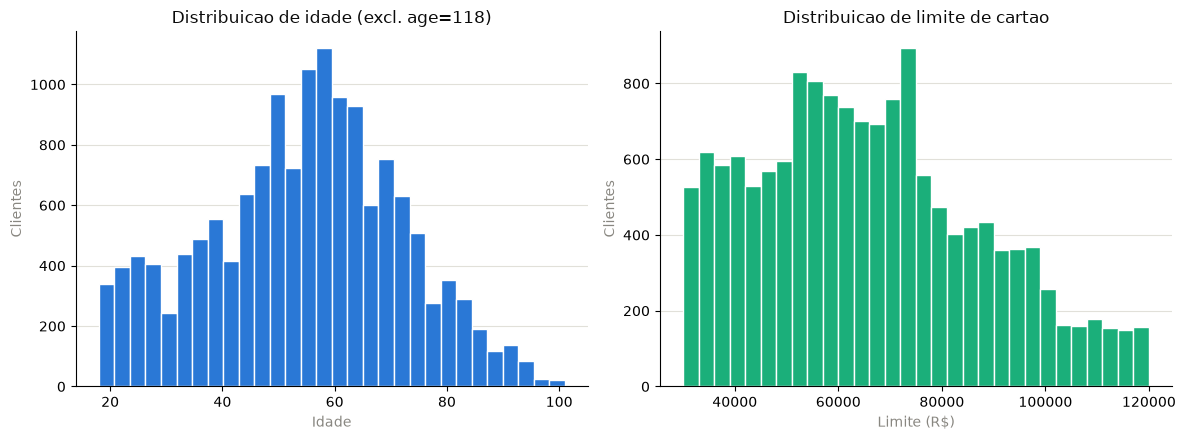

count    14825.000000
mean        54.393524
std         17.383705
min         18.000000
25%         42.000000
50%         55.000000
75%         66.000000
max        101.000000
Name: age, dtype: float64

count     14825.000000
mean      65404.991568
std       21598.299410
min       30000.000000
25%       49000.000000
50%       64000.000000
75%       80000.000000
max      120000.000000
Name: credit_card_limit, dtype: float64


In [10]:
profile_pd = profile_clean.select("age", "gender", "credit_card_limit").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(profile_pd["age"].dropna(), bins=30, color=COLOR_PRIMARY, edgecolor="white")
ax.set_title("Distribuicao de idade (excl. age=118)", color=INK, fontsize=12)
ax.set_xlabel("Idade", color=MUTED)
ax.set_ylabel("Clientes", color=MUTED)
style_ax(ax)

ax = axes[1]
ax.hist(profile_pd["credit_card_limit"].dropna(), bins=30, color=CAT_COLORS[1], edgecolor="white")
ax.set_title("Distribuicao de limite de cartao", color=INK, fontsize=12)
ax.set_xlabel("Limite (R$)", color=MUTED)
ax.set_ylabel("Clientes", color=MUTED)
style_ax(ax)

plt.tight_layout()
plt.show()

print(profile_pd["age"].describe())
print()
print(profile_pd["credit_card_limit"].describe())

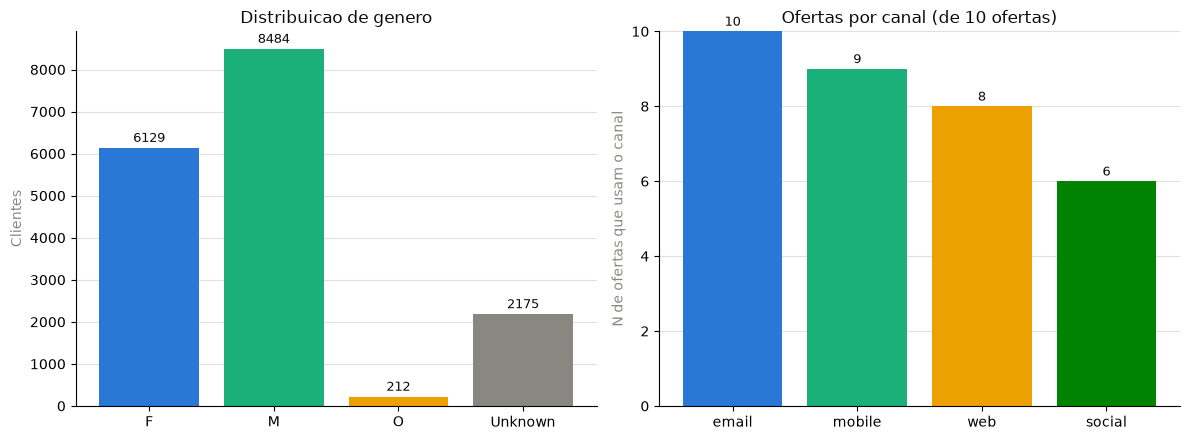

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

gender_counts = profile_pd["gender"].fillna("Unknown").value_counts().reindex(["F", "M", "O", "Unknown"])
gender_colors = [CAT_COLORS[0], CAT_COLORS[1], CAT_COLORS[2], UNKNOWN_COLOR]
ax = axes[0]
ax.bar(gender_counts.index, gender_counts.values, color=gender_colors)
ax.set_title("Distribuicao de genero", color=INK, fontsize=12)
ax.set_ylabel("Clientes", color=MUTED)
style_ax(ax)
for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 150, str(v), ha="center", color=INK, fontsize=9)

channels_pd = offers.select(F.explode("channels").alias("channel")).groupBy("channel").count().orderBy(F.desc("count")).toPandas()
ax = axes[1]
ax.bar(channels_pd["channel"], channels_pd["count"], color=CAT_COLORS[:len(channels_pd)])
ax.set_title("Ofertas por canal (de 10 ofertas)", color=INK, fontsize=12)
ax.set_ylabel("N de ofertas que usam o canal", color=MUTED)
ax.set_ylim(0, 10)
style_ax(ax)
for i, v in enumerate(channels_pd["count"]):
    ax.text(i, v + 0.15, str(v), ha="center", color=INK, fontsize=9)

plt.tight_layout()
plt.show()

**Conclusoes:**
- Idade concentra entre 35 e 75 anos (media 54,4, mediana 55), com cauda mais fina acima de 85 —
  distribuicao razoavelmente compacta, sem outliers extremos depois de remover o sentinel 118.
- Limite de cartao vai de R$30.000 a R$120.000 (media R$65.400, mediana R$64.000) — faixa estreita
  o suficiente pra nao precisar de escala log (ao contrario de datasets com cauda longa de valores
  monetarios).
- Genero: 8.484 homens, 6.129 mulheres, 212 "O", 2.175 "Unknown" (perfil incompleto) — base
  razoavelmente balanceada entre M/F, com o grupo "Unknown" relevante o bastante pra tratar
  separadamente (nao descartar).
- Canais: `email` esta em todas as 10 ofertas, `mobile` em 9, `web` em 8, `social` em apenas 6 —
  email e o canal "padrao", social e o mais seletivo. Isso importa pra secao 6.6 (canal x
  conversao): como quase toda oferta usa email, e dificil isolar o efeito do canal em si.

### 6.2 Idade x limite de credito

In [12]:
age_bucket_expr = (
    F.when(F.col("age").isNull(), "Unknown")
     .when(F.col("age") < 25, "18-24")
     .when(F.col("age") < 35, "25-34")
     .when(F.col("age") < 45, "35-44")
     .when(F.col("age") < 55, "45-54")
     .when(F.col("age") < 65, "55-64")
     .otherwise("65+")
)
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+", "Unknown"]

age_limit = (
    profile_clean.withColumn("age_group", age_bucket_expr)
    .groupBy("age_group")
    .agg(F.avg("credit_card_limit").alias("avg_limit"), F.count("*").alias("n"))
    .toPandas()
    .set_index("age_group").reindex(AGE_ORDER).reset_index()
)
age_limit

,age_group,avg_limit,n
0,18-24,50055.936073,876
1,25-34,51436.956522,1380
2,35-44,58073.836276,1869
3,45-54,67424.825755,3013
4,55-64,70604.209296,3421
5,65+,70691.279887,4266
6,Unknown,NaN,2175


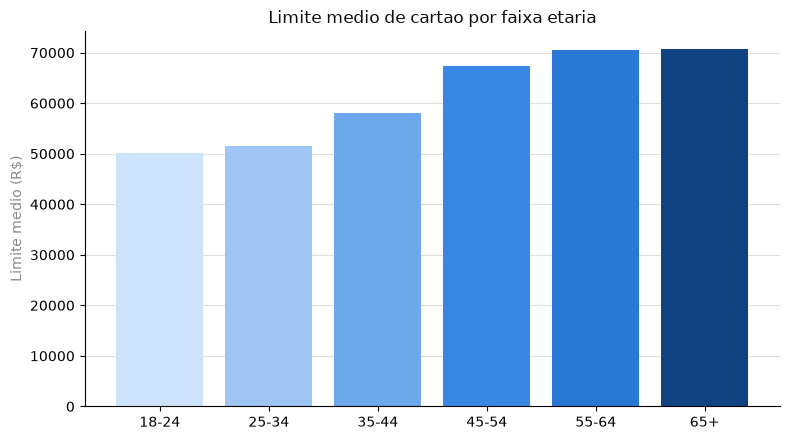

In [13]:
n_groups = len(AGE_ORDER) - 1  # exclui "Unknown" da rampa sequencial (nao tem ordem numerica)
ramp_idx = np.linspace(0, len(BLUE_RAMP) - 1, n_groups).astype(int)
bar_colors = [BLUE_RAMP[i] for i in ramp_idx] + [UNKNOWN_COLOR]

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = age_limit.dropna(subset=["avg_limit"])
ax.bar(plot_df["age_group"], plot_df["avg_limit"], color=bar_colors[:len(plot_df)])
ax.set_title("Limite medio de cartao por faixa etaria", color=INK, fontsize=12)
ax.set_ylabel("Limite medio (R$)", color=MUTED)
style_ax(ax)
plt.tight_layout()
plt.show()

**Conclusao:** ao contrario do que se poderia supor, limite de credito **nao** e independente de
idade nos nossos dados — ha um gradiente real: R$50.056 (18-24) subindo ate R$70.691 (65+), um
salto de ~41%, com o maior incremento entre 35-44 e 45-54. Isso sugere que `age` e
`credit_card_limit` carregam parte de sinal redundante — vale considerar isso ao montar features
pro modelo (não tratar as duas como totalmente independentes).

### 6.3 Distribuicao de eventos por tipo e por rodada

In [14]:
df_joined.groupBy("event").count().orderBy(F.desc("count")).show()

round_dist = opps_full.groupBy("round_day").count().orderBy("round_day").toPandas()
round_dist

+---------------+------+
|          event| count|
+---------------+------+
|    transaction|138953|
| offer received| 76277|
|   offer viewed| 57725|
|offer completed| 33579|
+---------------+------+



,round_day,count
0,0,12650
1,7,12669
2,14,12711
3,17,12778
4,21,12704
5,24,12765


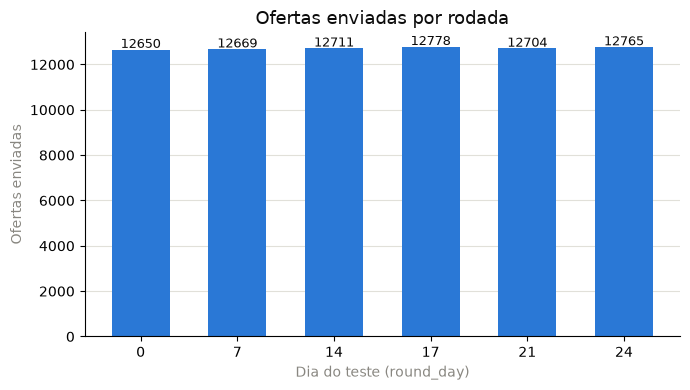

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(round_dist["round_day"].astype(str), round_dist["count"], color=COLOR_PRIMARY, width=0.6)
ax.set_title("Ofertas enviadas por rodada", color=INK, fontsize=13)
ax.set_xlabel("Dia do teste (round_day)", color=MUTED)
ax.set_ylabel("Ofertas enviadas", color=MUTED)
style_ax(ax)
for i, v in enumerate(round_dist["count"]):
    ax.text(i, v + 80, str(v), ha="center", color=INK, fontsize=9)
plt.tight_layout()
plt.show()

O envio e bem equilibrado entre as 6 rodadas (~12.650 a 12.780 ofertas por rodada).

### 6.4 Taxa de visualizacao e de conclusao por oferta

In [16]:
by_type = opps_full.groupBy("offer_type").agg(
    F.count("*").alias("n"),
    F.avg("viewed").alias("view_rate"),
    F.avg("completed").alias("completion_rate"),
    F.avg("informational_success").alias("informational_success_rate"),
).orderBy("offer_type")
by_type.show()

+-------------+-----+------------------+------------------+--------------------------+
|   offer_type|    n|         view_rate|   completion_rate|informational_success_rate|
+-------------+-----+------------------+------------------+--------------------------+
|         bogo|30499|0.8318961277418931|0.5137545493294862|                      NULL|
|     discount|30543| 0.705857315915267|0.5880889238123301|                      NULL|
|informational|15235|0.6540203478831638|               0.0|        0.3910731867410568|
+-------------+-----+------------------+------------------+--------------------------+



In [17]:
by_offer = opps_full.groupBy(
    "offer_id", "offer_type", "discount_value", "min_value", "duration"
).agg(
    F.count("*").alias("n"),
    F.avg("viewed").alias("view_rate"),
    F.avg("completed").alias("completion_rate"),
).orderBy("offer_type", F.desc("completion_rate")).toPandas()
by_offer

,offer_id,offer_type,discount_value,min_value,duration,n,view_rate,completion_rate
0,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,5.0,7571,0.954696,0.567428
1,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,7.0,7677,0.544223,0.567149
2,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,7.0,7658,0.877253,0.481588
3,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,5.0,7593,0.954563,0.438694
4,fafdcd668e3743c1bb461111dcafc2a4,discount,2,10,10.0,7597,0.968145,0.701856
5,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,3,7,7.0,7646,0.961679,0.675517
6,2906b810c7d4411798c6938adc9daaa5,discount,2,10,7.0,7632,0.539701,0.527385
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,5,20,10.0,7668,0.356286,0.448618
8,3f207df678b143eea3cee63160fa8bed,informational,0,0,4.0,7617,0.500459,0.000000
9,5a8bc65990b245e5a138643cd4eb9837,informational,0,0,3.0,7618,0.807561,0.000000


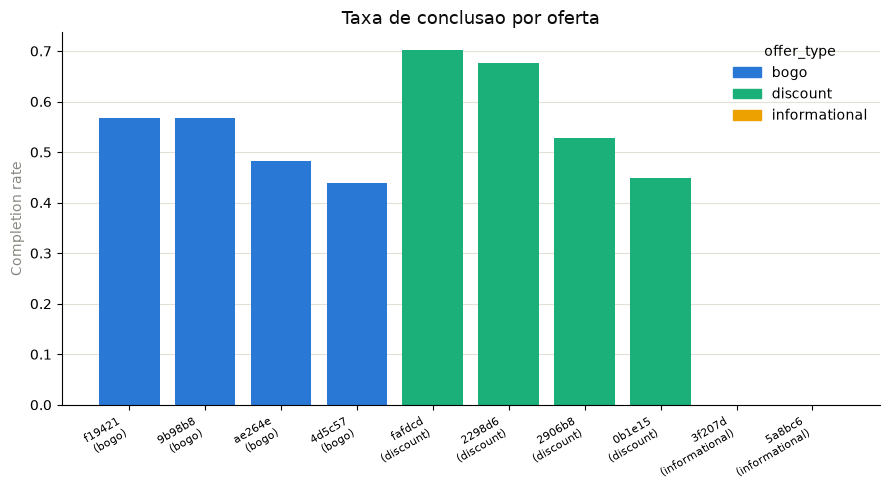

In [18]:
type_colors = {"bogo": CAT_COLORS[0], "discount": CAT_COLORS[1], "informational": CAT_COLORS[2]}
colors = by_offer["offer_type"].map(type_colors)

fig, ax = plt.subplots(figsize=(9, 5))
labels = by_offer["offer_id"].str[:6] + "\n(" + by_offer["offer_type"] + ")"
ax.bar(labels, by_offer["completion_rate"], color=colors)
ax.set_title("Taxa de conclusao por oferta", color=INK, fontsize=13)
ax.set_ylabel("Completion rate", color=MUTED)
style_ax(ax)
plt.xticks(rotation=30, ha="right", fontsize=8)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in type_colors.values()]
ax.legend(handles, type_colors.keys(), title="offer_type", frameon=False)
plt.tight_layout()
plt.show()

Ofertas do tipo `informational` nao tem evento de conclusao (nao existe "offer completed" para
esse tipo) - por isso sua completion_rate e sempre 0; o sucesso desse tipo e medido separadamente
na secao 6.12.

### 6.5 Conversores organicos: completou sem visualizar

O funil (secao 6.4) mostra que nem todo mundo que ve a oferta completa ela — mas o caminho
inverso tambem existe: clientes que completam uma oferta **sem nunca ter visualizado ela** dentro
da janela. Isso importa porque sao conversoes que provavelmente aconteceriam de qualquer jeito,
nao por causa da oferta — o primeiro sinal real de que a taxa de conclusao bruta (secao 6.4) nao
mede o efeito causal da oferta, so correlacao.

In [19]:
bd = opps_full.filter(F.col("offer_type").isin("bogo", "discount")).withColumn("age_group", age_bucket_expr)
completed_bd = bd.filter(F.col("completed") == 1)

n_completed = completed_bd.count()
n_organic = completed_bd.filter(F.col("viewed") == 0).count()
print(f"Completou com view previa: {n_completed - n_organic} ({(n_completed - n_organic)/n_completed:.1%})")
print(f"Completou SEM view previa (organico): {n_organic} ({n_organic/n_completed:.1%})")

Completou com view previa: 27897 (83.0%)
Completou SEM view previa (organico): 5734 (17.0%)


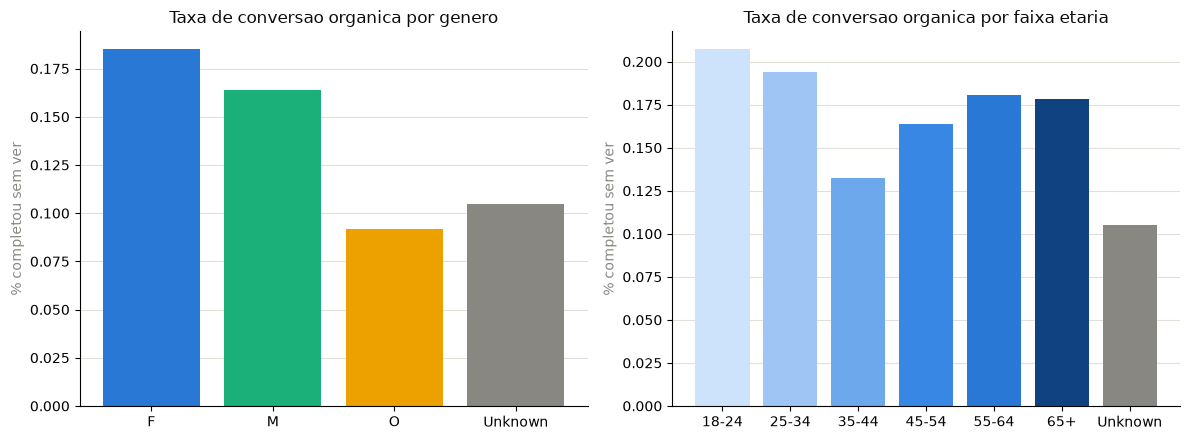

In [20]:
organic_by_gender = completed_bd.groupBy("gender").agg(
    F.avg((F.col("viewed") == 0).cast("int")).alias("organic_rate"),
    F.count("*").alias("n_completed"),
).toPandas().set_index("gender").reindex(GENDER_ORDER).reset_index()

organic_by_age = completed_bd.groupBy("age_group").agg(
    F.avg((F.col("viewed") == 0).cast("int")).alias("organic_rate"),
    F.count("*").alias("n_completed"),
).toPandas().set_index("age_group").reindex(AGE_ORDER).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
colors_g = [CAT_COLORS[0], CAT_COLORS[1], CAT_COLORS[2], UNKNOWN_COLOR]
ax.bar(organic_by_gender["gender"], organic_by_gender["organic_rate"], color=colors_g)
ax.set_title("Taxa de conversao organica por genero", color=INK, fontsize=12)
ax.set_ylabel("% completou sem ver", color=MUTED)
style_ax(ax)

ax = axes[1]
n_age = len(AGE_ORDER) - 1
ramp_idx = np.linspace(0, len(BLUE_RAMP) - 1, n_age).astype(int)
colors_a = [BLUE_RAMP[i] for i in ramp_idx] + [UNKNOWN_COLOR]
ax.bar(organic_by_age["age_group"], organic_by_age["organic_rate"], color=colors_a)
ax.set_title("Taxa de conversao organica por faixa etaria", color=INK, fontsize=12)
ax.set_ylabel("% completou sem ver", color=MUTED)
style_ax(ax)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Conclusoes:**
- **17,0% das conclusoes (5.734 de 33.631)** acontecem sem visualizacao previa da oferta dentro
  da janela — quase 1 em cada 6 "conversoes" ja teria acontecido sem a oferta existir.
- Mulheres tem taxa organica ligeiramente maior que homens (18,5% vs 16,4%) — como mulheres ja
  convertem mais no geral (secao 6.8), isso levanta a duvida de quanto desse gap por genero e
  efeito real da oferta vs. comportamento de compra que já existia antes.
- A faixa 35-44 tem a menor taxa organica (13,2%) — e o segmento que mais depende de ver a
  oferta pra agir, o que o torna o mais responsivo a uma boa estrategia de distribuicao.
- **Isso e o argumento mais concreto da EDA pra tratar isso como problema de incrementalidade,
  nao so propensao**: a taxa de conclusao bruta mistura "quem converteu por causa da oferta" com
  "quem converteria de qualquer jeito". Um modelo de propensao simples otimizaria pra atingir
  quem tem MAIOR chance de organic conversion — o oposto do que se quer. Isso reforca a escolha
  de um bandit que aprende com tentativa e recompensa observada (e pode, em tese, aprender a nao
  gastar oferta em quem converteria de qualquer jeito) em vez de um modelo estatico de propensao.

### 6.6 Duracao x conversao

In [21]:
duration_conv = (
    opps_full.filter(F.col("offer_type").isin("bogo", "discount"))
    .groupBy("duration", "offer_type")
    .agg(F.avg("completed").alias("completion_rate"), F.count("*").alias("n"))
    .orderBy("duration", "offer_type")
    .toPandas()
)
duration_conv

,duration,offer_type,completion_rate,n
0,5.0,bogo,0.502968,15164
1,7.0,bogo,0.524421,15335
2,7.0,discount,0.601519,15278
3,10.0,discount,0.574648,15265


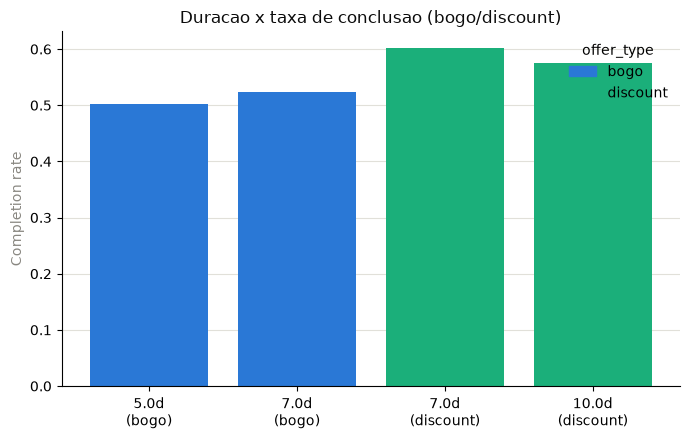

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x_labels = duration_conv["duration"].astype(str) + "d\n(" + duration_conv["offer_type"] + ")"
bar_colors = duration_conv["offer_type"].map(type_colors)
ax.bar(x_labels, duration_conv["completion_rate"], color=bar_colors)
ax.set_title("Duracao x taxa de conclusao (bogo/discount)", color=INK, fontsize=12)
ax.set_ylabel("Completion rate", color=MUTED)
style_ax(ax)
handles = [plt.Rectangle((0,0),1,1, color=type_colors[t]) for t in ["bogo", "discount"]]
ax.legend(handles, ["bogo", "discount"], title="offer_type", frameon=False)
plt.tight_layout()
plt.show()

**Conclusao:** dentro do mesmo `offer_type`, variar a duracao muda pouco a conclusao — bogo vai
de 50,3% (5 dias) a 52,4% (7 dias); discount vai de 60,2% (7 dias) a 57,5% (10 dias, ate cai um
pouco com mais tempo). Nao ha efeito de urgencia claro. O tipo da oferta (bogo vs. discount)
explica muito mais variacao do que a duracao em si — durduracao provavelmente funciona mais como
proxy do tipo de oferta do que como alavanca independente.

### 6.7 Canal x conversao, por tipo de oferta

In [23]:
opps_channel = (
    opps_full.select("offer_type", "completed", "channels")
    .withColumn("channel", F.explode("channels"))
    .groupBy("offer_type", "channel")
    .agg(F.avg("completed").alias("completion_rate"), F.count("*").alias("n"))
    .orderBy("offer_type", "channel")
    .toPandas()
)
opps_channel

,offer_type,channel,completion_rate,n
0,bogo,email,0.513755,30499
1,bogo,mobile,0.513755,30499
2,bogo,social,0.495794,22822
3,bogo,web,0.524539,22841
4,discount,email,0.588089,30543
5,discount,mobile,0.634842,22875
6,discount,social,0.688644,15243
7,discount,web,0.588089,30543
8,informational,email,0.000000,15235
9,informational,mobile,0.000000,15235


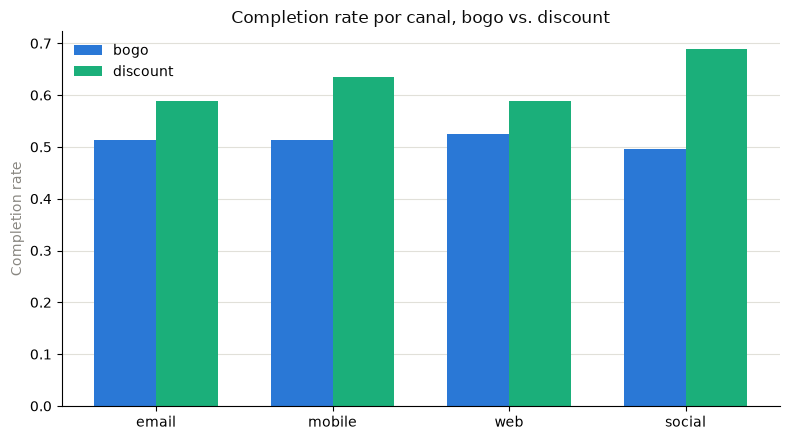

In [24]:
CHANNEL_ORDER = ["email", "mobile", "web", "social"]
pivot = opps_channel.pivot(index="channel", columns="offer_type", values="completion_rate").reindex(CHANNEL_ORDER)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(pivot.index))
width = 0.35
ax.bar(x - width/2, pivot["bogo"], width, label="bogo", color=type_colors["bogo"])
ax.bar(x + width/2, pivot["discount"], width, label="discount", color=type_colors["discount"])
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_title("Completion rate por canal, bogo vs. discount", color=INK, fontsize=12)
ax.set_ylabel("Completion rate", color=MUTED)
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusao:** `discount` supera `bogo` em todo canal (58-69% vs 50-52%) — de novo, o tipo de
oferta pesa mais que o canal. Dentro de `discount`, `social` se destaca com 68,9% — mas cuidado
na leitura: **canal aqui e um atributo fixo da campanha de cada oferta** (quais canais aquela
oferta usa), nao qual canal especifico entregou a oferta pro cliente individual — os dados nao
registram isso. Como `email` esta presente em quase todas as ofertas (10/10) e `social` so em 6,
uma completion_rate maior em `social` pode refletir **quais ofertas especificas** usam esse canal,
nao um efeito causal do canal em si. Tratar com cautela antes de recomendar "mandar mais por
social".

### 6.8 Perfil de clientes: quem converte vs. quem nao converte

In [25]:
converters = (
    opps_full.filter(F.col("offer_type").isin("bogo", "discount"))
    .groupBy("completed")
    .agg(
        F.avg("age").alias("avg_age"),
        F.avg("credit_card_limit").alias("avg_credit_limit"),
        F.count("*").alias("n"),
    )
)
converters.show()

+---------+------------------+-----------------+-----+
|completed|           avg_age| avg_credit_limit|    n|
+---------+------------------+-----------------+-----+
|        1| 55.82123283453414| 69412.1559209311|33631|
|        0|51.971336196496644|59039.03874921585|27411|
+---------+------------------+-----------------+-----+



Clientes que completam ofertas (bogo/discount) tendem a ser mais velhos e ter limite de cartao
mais alto do que os que nao completam — um sinal util para segmentacao/features na modelagem.

In [26]:
gender_age = (
    opps_full.withColumn("age_group", age_bucket_expr)
    .filter(F.col("offer_type").isin("bogo", "discount"))
    .groupBy("gender", "age_group")
    .agg(F.avg("completed").alias("completion_rate"), F.count("*").alias("n"))
    .toPandas()
)

GENDER_ORDER = ["F", "M", "O", "Unknown"]
heat = gender_age.pivot(index="gender", columns="age_group", values="completion_rate").reindex(
    index=GENDER_ORDER, columns=AGE_ORDER
)
heat

age_group,18-24,25-34,35-44,45-54,55-64,65+,Unknown
gender,,,,,,,
F,0.611111,0.644764,0.691064,0.718297,0.726069,0.712811,NaN
M,0.407212,0.430659,0.524136,0.558109,0.583784,0.584251,NaN
O,0.406250,0.600000,0.644860,0.786207,0.737705,0.688442,NaN
Unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.147048


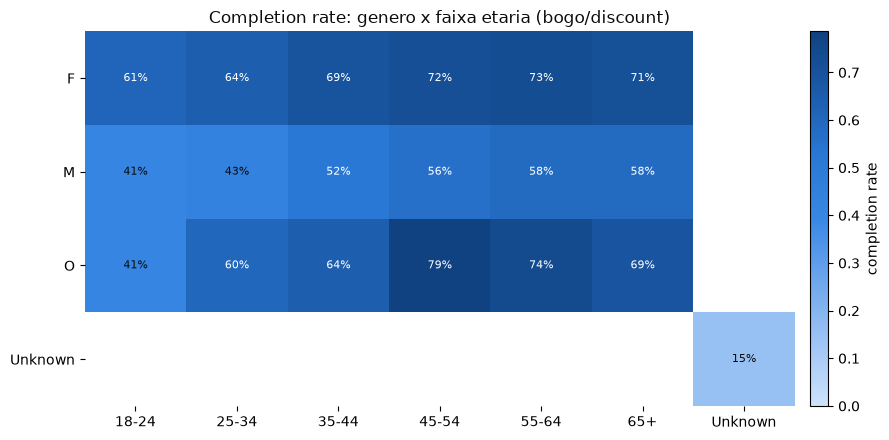

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(heat.values, cmap=SEQ_CMAP, aspect="auto", vmin=0, vmax=heat.values[~np.isnan(heat.values)].max())

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Completion rate: genero x faixa etaria (bogo/discount)", color=INK, fontsize=12)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        if not np.isnan(val):
            text_color = "white" if val > 0.45 else INK
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", color=text_color, fontsize=8)

for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, label="completion rate", fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()

**Conclusoes:**
- **Mulheres completam mais que homens em todas as faixas etarias**, sem excecao — a diferenca
  chega a ~16 p.p. na faixa 45-54 (71,8% F vs 55,8% M).
- Dentro de cada genero, a conclusao cresce com a idade ate estabilizar por volta de 45-54 anos.
- **O grupo "Unknown" (perfil incompleto) converte muito menos que qualquer segmento com dado
  completo: 14,7%**, contra 41-73% nos demais — o dado faltante em si carrega sinal (provavelmente
  cadastros mais antigos/menos engajados, ou contas de teste). Vale considerar um flag de "perfil
  incompleto" como feature, nao so imputar e seguir.

### 6.9 Gasto: quem usa oferta vs. quem nao usa

In [28]:
completers = (
    opps_full.filter((F.col("offer_type").isin("bogo", "discount")) & (F.col("completed") == 1))
    .select("customer_id").distinct()
)
tx_amounts = df_joined.filter(F.col("event") == "transaction").select("customer_id", "amount")

tx_labeled = (
    tx_amounts.join(completers.withColumn("is_offer_user", F.lit(1)), on="customer_id", how="left")
    .withColumn("is_offer_user", F.coalesce(F.col("is_offer_user"), F.lit(0)))
)

spend_summary = tx_labeled.groupBy("is_offer_user").agg(
    F.avg("amount").alias("avg_amount"),
    F.expr("percentile_approx(amount, 0.5)").alias("median_amount"),
    F.count("*").alias("n_transactions"),
).toPandas()
spend_summary

,is_offer_user,avg_amount,median_amount,n_transactions
0,1,14.378468,11.36,118178
1,0,3.669474,2.15,20775


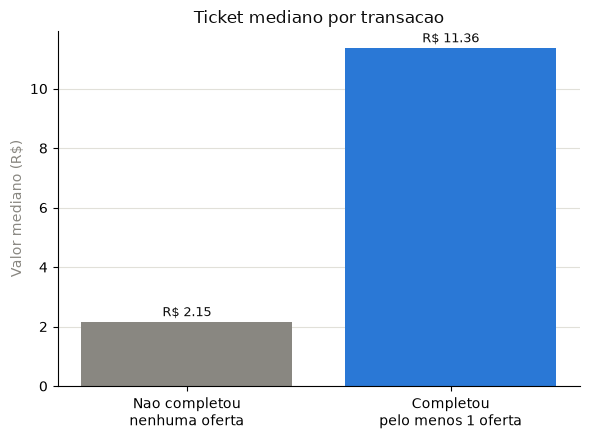

In [29]:
fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["Nao completou\nnenhuma oferta", "Completou\npelo menos 1 oferta"]
bar_colors = [MUTED, COLOR_PRIMARY]
values = spend_summary.sort_values("is_offer_user")["median_amount"]
ax.bar(labels, values, color=bar_colors)
ax.set_title("Ticket mediano por transacao", color=INK, fontsize=12)
ax.set_ylabel("Valor mediano (R$)", color=MUTED)
style_ax(ax)
for i, v in enumerate(values):
    ax.text(i, v + 0.2, f"R$ {v:.2f}", ha="center", color=INK, fontsize=9)
plt.tight_layout()
plt.show()

**Conclusao:** clientes que completam pelo menos uma oferta tem ticket mediano de **R$11,36**,
contra **R$2,15** de quem nunca completa — quase 4x maior (media R$14,38 vs R$3,67). Isso e
**correlacao, nao causalidade**: e esperado que clientes que ja gastam mais tenham mais chance de
bater o `min_value` de qualquer oferta, então parte desse gasto teria acontecido de qualquer jeito
(autosselecao). Nao dá pra usar esse numero direto como "impacto da oferta" — fica marcado aqui
como um limite conhecido da EDA, relevante pra quando formos estimar impacto de verdade.

### 6.10 Padrao temporal: por semana e coorte de cadastro

In [30]:
weekly = (
    df_joined.withColumn("week", (F.col("time_since_test_start") / 7).cast("int"))
    .filter(F.col("event").isin("offer viewed", "offer completed"))
    .groupBy("week", "event")
    .count()
    .toPandas()
)
weekly_pivot = weekly.pivot(index="week", columns="event", values="count").fillna(0)
weekly_pivot

event,offer completed,offer viewed
week,,
0,4658,9943
1,5509,10104
2,10289,18426
3,12026,18597
4,1097,655


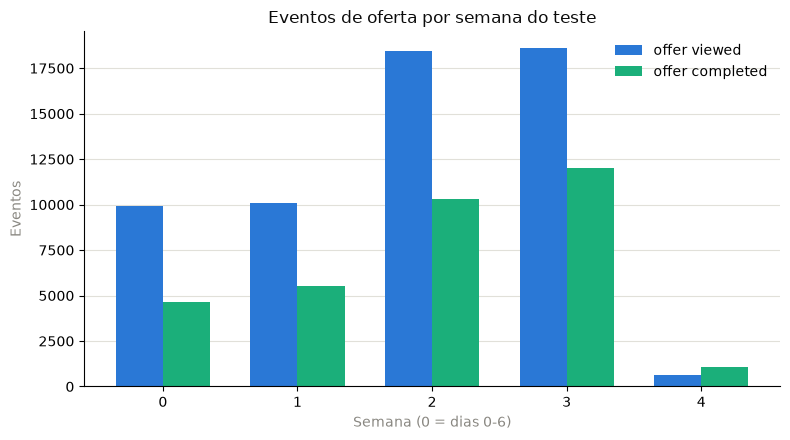

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(weekly_pivot.index))
width = 0.35
ax.bar(x - width/2, weekly_pivot["offer viewed"], width, label="offer viewed", color=CAT_COLORS[0])
ax.bar(x + width/2, weekly_pivot["offer completed"], width, label="offer completed", color=CAT_COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(weekly_pivot.index)
ax.set_title("Eventos de oferta por semana do teste", color=INK, fontsize=12)
ax.set_xlabel("Semana (0 = dias 0-6)", color=MUTED)
ax.set_ylabel("Eventos", color=MUTED)
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Volume de `viewed`/`completed` cresce ate a semana 3, e cai na semana 4 — mas isso e truncamento
esperado (o teste tem ~29 dias, entao a semana 4 so tem 1-2 dias de dados, nao um sinal de fadiga
do cliente).

In [32]:
cohort = (
    opps_full.join(df_joined.select("customer_id", "registered_on_date").distinct(), on="customer_id", how="left")
    .withColumn("reg_year", F.year("registered_on_date"))
    .filter(F.col("offer_type").isin("bogo", "discount"))
    .groupBy("reg_year")
    .agg(F.avg("completed").alias("completion_rate"), F.count("*").alias("n"))
    .orderBy("reg_year")
    .toPandas()
)
cohort

,reg_year,completion_rate,n
0,2013,0.554908,1029
1,2014,0.540235,2473
2,2015,0.682198,6589
3,2016,0.740296,12572
4,2017,0.544309,23178
5,2018,0.349056,15201


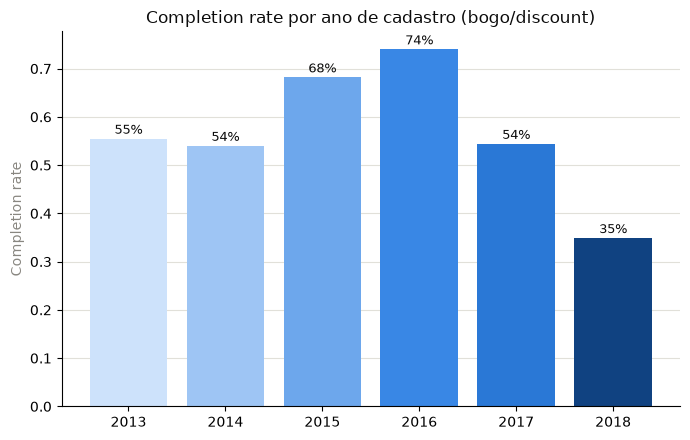

In [33]:
n_years = len(cohort)
ramp_idx = np.linspace(0, len(BLUE_RAMP) - 1, n_years).astype(int)
bar_colors = [BLUE_RAMP[i] for i in ramp_idx]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(cohort["reg_year"].astype(str), cohort["completion_rate"], color=bar_colors)
ax.set_title("Completion rate por ano de cadastro (bogo/discount)", color=INK, fontsize=12)
ax.set_ylabel("Completion rate", color=MUTED)
style_ax(ax)
for i, v in enumerate(cohort["completion_rate"]):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center", color=INK, fontsize=9)
plt.tight_layout()
plt.show()

**Conclusao:** o padrao **nao e uma tendencia monotonica limpa** de "quanto mais antigo, mais
converte" — a coorte de 2016 e a que mais converte (74,0%), nao a mais antiga (2013, 55,5%). O que
fica claro e o oposto: a **coorte mais nova (2018) converte visivelmente menos (34,9%)**, bem
abaixo de todas as outras — um efeito de "cliente novo" real, mesmo que o resto da serie não seja
monotonico. `customer_tenure_days` (ou um flag "cliente novo") parece um sinal mais confiavel do
que o ano de cadastro isolado.

### 6.11 Repeticao de ofertas

In [34]:
w = Window.partitionBy("customer_id", "offer_id").orderBy("t_received")
opps_ranked = opps_full.withColumn("instance_rank", F.row_number().over(w))

n_repeat_customers = (
    opps_full.groupBy("customer_id", "offer_id").count().filter("count > 1").count()
)
print(f"Grupos (cliente, oferta) com mais de um envio: {n_repeat_customers}")

opps_ranked.filter(F.col("offer_type").isin("bogo", "discount")).groupBy(
    (F.col("instance_rank") == 1).alias("is_first_instance")
).agg(F.avg("completed").alias("completion_rate"), F.count("*").alias("n")).show()

Grupos (cliente, oferta) com mais de um envio: 11718


+-----------------+------------------+-----+
|is_first_instance|   completion_rate|    n|
+-----------------+------------------+-----+
|             true|0.5487686869285305|50637|
|            false|0.5615569437770302|10405|
+-----------------+------------------+-----+



Repetir o envio da mesma oferta para o mesmo cliente nao reduz a taxa de conclusao (na verdade
e ligeiramente maior na repeticao) — nao ha sinal de fadiga forte no historico observado.

### 6.12 Ofertas informationais

In [35]:
info = opps_full.filter(F.col("offer_type") == "informational")
info.groupBy("viewed", "informational_success").count().orderBy("viewed", "informational_success").show()

+------+---------------------+-----+
|viewed|informational_success|count|
+------+---------------------+-----+
|     0|                    0| 5271|
|     1|                    0| 4006|
|     1|                    1| 5958|
+------+---------------------+-----+



Premissa: uma oferta informational so e considerada "bem-sucedida" se o cliente (a) visualizou a
oferta E (b) fez uma transacao depois da visualizacao e dentro da janela de duracao — visualizar
e um pre-requisito, ja que nao faz sentido atribuir a oferta a uma compra que ela nunca poderia
ter influenciado.

### 6.13 Checagem de qualidade da tabela de oportunidades

In [36]:
# nulos no profile
profile_clean.select(
    F.sum(F.col("age").isNull().cast("int")).alias("age_null"),
    F.sum((F.col("gender") == "Unknown").cast("int")).alias("gender_unknown"),
    F.sum(F.col("credit_card_limit").isNull().cast("int")).alias("limit_null"),
    F.count("*").alias("n_total"),
).show()

# reward vs discount_value (consistencia ja usada como premissa de que reward = custo do desconto)
df_joined.filter(F.col("event") == "offer completed").select(
    (F.col("reward") == F.col("discount_value")).alias("matches")
).groupBy("matches").count().show()

# diferenca entre "offer completed" brutos e a soma de completed na tabela de oportunidades
raw_completed = df_joined.filter(F.col("event") == "offer completed").count()
opp_completed = opps_full.agg(F.sum("completed")).collect()[0][0]
print(f"Eventos 'offer completed' brutos: {raw_completed}")
print(f"Soma de 'completed' na tabela de oportunidades: {opp_completed}")
print(f"Diferenca: {opp_completed - raw_completed}")

+--------+--------------+----------+-------+
|age_null|gender_unknown|limit_null|n_total|
+--------+--------------+----------+-------+
|    2175|          2175|      2175|  17000|
+--------+--------------+----------+-------+



+-------+-----+
|matches|count|
+-------+-----+
|   true|33579|
+-------+-----+



Eventos 'offer completed' brutos: 33579
Soma de 'completed' na tabela de oportunidades: 33631
Diferenca: 52


**Sobre a diferenca de +52:** quando a mesma oferta e enviada duas vezes ao mesmo cliente com
janelas sobrepostas (possivel porque algumas rodadas ficam so 3-4 dias uma da outra), um unico
evento de `offer completed` pode cair dentro da janela de ambas as instancias e ser contado duas
vezes. Afeta 52 de 33.579 conclusoes (~0.15%) — marginal, mas registrado aqui como premissa
assumida em vez de escondido.

## 7. Persistencia

In [37]:
output_path = "../data/processed/opportunities"
opps_full.write.mode("overwrite").parquet(output_path)
print(f"Tabela de oportunidades salva em {output_path}")

# leitura de volta para conferir
spark.read.parquet(output_path).count()

Tabela de oportunidades salva em ../data/processed/opportunities


76277

## Premissas e observacoes

- `age == 118` tratado como valor ausente (sentinel), assim como `gender`/`credit_card_limit`
  nulos associados (mesmos ~2.175 clientes com perfil incompleto) — e o mesmo grupo de clientes
  nas tres colunas, nao problemas independentes.
- Atribuicao de ofertas assumida como proxima de aleatoria (idade/genero/limite sao homogeneos
  entre as 10 ofertas) — relevante para qualquer avaliacao offline futura de politica de
  recomendacao.
- Grao da tabela de oportunidades e por instancia de envio, nao por par (cliente, oferta)
  agregado — necessario porque clientes podem receber a mesma oferta mais de uma vez.
- Oferta `informational` so e considerada bem-sucedida se houve visualizacao seguida de uma
  transacao dentro da janela (visualizar e pre-requisito).
- Ha uma sobreposicao rara de janelas entre instancias repetidas da mesma oferta ao mesmo
  cliente, que pode contar um unico evento de conclusao para duas instancias (+52 de 33.579,
  ~0.15%) — aceito como simplificacao documentada.
- `round_day` (0/7/14/17/21/24) reflete rodadas de envio sincronizadas identificadas nos dados —
  relevante para a proxima etapa de modelagem.
- `channels` em `offers.json` e um atributo da campanha (quais canais aquela oferta usa), nao o
  canal que efetivamente entregou a oferta a um cliente especifico — os dados nao permitem
  atribuicao por canal individual, so por composicao de campanha.
- O gasto maior de quem completa ofertas (~4x) e tratado como correlacao/autosselecao, nao como
  evidencia de causalidade da oferta — fica para o notebook de modelagem separar isso de verdade.

**Fora de escopo deste notebook:** desenho do modelo/bandit de recomendacao de ofertas
(notebook 2) e a apresentacao final.